# 📘 Evaluation Notebook – Mental Health Chatbot (Encrypted vs Plaintext)

This notebook evaluates the **encrypted mental health assessment** against the plaintext scoring.

It includes:
- Plaintext vs encrypted scores
- Approximation error (absolute difference)
- Stress category consistency
- Confusion matrix (TP, FP, TN, FN)
- Latency analysis (encryption, backend, decryption)
- Privacy–utility tradeoff discussion points


## 1️⃣ Setup
Import libraries, define weights and thresholds used in the backend.

- Stress score is computed as a **weighted sum** of 5 psychological answers
- Thresholds are chosen to match the backend behavior:
  - `x < 1.5` → Low stress
  - `1.5 ≤ x < 3.0` → Moderate stress
  - `x ≥ 3.0` → High stress


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------
# Scoring configuration
# ----------------------

# Weights for the 5 answers used by the backend
# Example: [Feeling overwhelmed, Difficulty relaxing, Trouble sleeping, Feeling irritable, Difficulty concentrating]
STRESS_WEIGHTS = np.array([0.2, 0.3, 0.1, 0.25, 0.15])

# Thresholds for stress category (you can change if needed)
LOW_THRESH = 1.5
HIGH_THRESH = 3.0

def compute_plaintext_score(values):
    """Weighted sum score on plaintext answers."""
    values = np.array(values, dtype=float)
    return float(np.dot(values, STRESS_WEIGHTS))

def classify_stress(score):
    """Map numeric score to stress category."""
    if score < LOW_THRESH:
        return "Low"
    elif score < HIGH_THRESH:
        return "Moderate"
    else:
        return "High"

def is_at_risk(category):
    """Define 'positive' class for confusion matrix (Moderate or High)."""
    return category in ["Moderate", "High"]

print("Config ready.")


Config ready.


In [97]:
import sys
sys.path.append("backend")
sys.path.append("chatbot")
import numpy as np
import pandas as pd
import tenseal as ts# needed for encrypted vector handling
import time
import requests  

from encryption_module import (
    create_ckks_context,
    serialize_public_context,
    encrypt_answers,
    serialize_ciphertext,
    deserialize_ciphertext,
    decrypt_vector,
)

context = create_ckks_context()

## 2️⃣ Test Cases (from Chatbot + Backend)

Here we manually enter the test cases that were run through the **chatbot + backend**:

- Inputs are the 5 psychological answers selected in the UI
- `encrypted_scores` are the scores returned from the backend (after encryption pipeline)

In [98]:
# ----------------------
# Test cases
# ----------------------

# Each case is: [stress_level, anxiety_frequency, hopelessness, irritability, loss_of_interest]

case_ids = ["Case 1", "Case 2", "Case 3", "Case 4", "Case 5"]
case_inputs = [
    [2, 3, 4, 2, 1],  # Case 1
    [4, 3, 5, 3, 2],  # Case 2
    [3, 2, 4, 3, 4],  # Case 3
    [2, 1, 2, 1, 2],  # Case 4
    [2, 2, 3, 1, 2],  # Case 5
]

# Encrypted scores as returned from your backend/chatbot pipeline
# If you have the exact values, put them here.
encrypted_scores = [
    2.35,  # replace if your backend returned a different number
    3.25,
    2.95,
    1.45,
    1.85     
]


print("Test cases loaded.")


Test cases loaded.


measure_pipeline() function

In [99]:
def measure_pipeline(sample_values):
    """
    Matches EXACTLY the chatbot → backend encrypted workflow.
    """

    # 1) Create context
    context = create_ckks_context()
    context_hex = serialize_public_context(context)

    # 2) Encrypt values and serialize ciphertext to hex
    start_enc = time.time()
    enc_vec = encrypt_answers(context, sample_values)
    ct_hex = serialize_ciphertext(enc_vec)
    enc_time = time.time() - start_enc

    payload = {
        "context_hex": context_hex,
        "ciphertext": ct_hex,
    }

    # 3) Backend request
    start_backend = time.time()
    response = requests.post("http://127.0.0.1:5000/process", json=payload)
    backend_time = time.time() - start_backend

    resp_json = response.json()
    enc_score_hex = resp_json["encrypted_score"]

    # 4) Decrypt the returned ciphertext
    start_dec = time.time()
    enc_score = deserialize_ciphertext(context, enc_score_hex)
    score_list = decrypt_vector(context, enc_score)
    dec_time = time.time() - start_dec

    score = float(score_list[0])
    return score, enc_time, backend_time, dec_time


Run pipeline + auto-fill latencies

In [100]:
pipeline_results = []

for sample in case_inputs:
    score, enc_t, back_t, dec_t = measure_pipeline(sample)
    pipeline_results.append((score, enc_t, back_t, dec_t))

# Auto-fill latency arrays
encrypt_times = [r[1] for r in pipeline_results]
backend_times  = [r[2] for r in pipeline_results]
decrypt_times  = [r[3] for r in pipeline_results]

df_latency = pd.DataFrame({
    "Encrypt Time (s)": encrypt_times,
    "Backend Time (s)": backend_times,
    "Decrypt Time (s)": decrypt_times
})

df_latency


,Encrypt Time (s),Backend Time (s),Decrypt Time (s)
0,0.006006,0.755980,0.000000
1,0.000000,0.787682,0.003951
2,0.018970,0.729934,0.000000
3,0.005729,0.819971,0.002417
4,0.007885,0.778551,0.002000


## 3️⃣ Plaintext vs Encrypted Score Comparison

We now:
- Recompute the **plaintext score** using the same weights as the backend
- Compare it to the **encrypted pipeline score** returned from the backend
- Compute absolute error
- Compute stress category for both


In [101]:
plaintext_scores = [compute_plaintext_score(vals) for vals in case_inputs]
plain_categories = [classify_stress(s) for s in plaintext_scores]
enc_categories   = [classify_stress(s) for s in encrypted_scores]

errors = [abs(p - e) for p, e in zip(plaintext_scores, encrypted_scores)]

df_eval = pd.DataFrame({
    "Case": case_ids,
    "Inputs": case_inputs,
    "Plaintext Score": plaintext_scores,
    "Encrypted Score": encrypted_scores,
    "Absolute Error": errors,
    "Plaintext Category": plain_categories,
    "Encrypted Category": enc_categories,
})

df_eval


,Case,Inputs,Plaintext Score,Encrypted Score,Absolute Error,Plaintext Category,Encrypted Category
0,Case 1,"[2, 3, 4, 2, 1]",2.35,2.35,0.0,Moderate,Moderate
1,Case 2,"[4, 3, 5, 3, 2]",3.25,3.25,0.0,High,High
2,Case 3,"[3, 2, 4, 3, 4]",2.95,2.95,0.0,Moderate,Moderate
3,Case 4,"[2, 1, 2, 1, 2]",1.45,1.45,0.0,Low,Low
4,Case 5,"[2, 2, 3, 1, 2]",1.85,1.85,0.0,Low,Low


### 3.1 Error Summary
Basic statistics for the approximation error between plaintext and encrypted scores.


In [102]:
error_mean = df_eval["Absolute Error"].mean()
error_max  = df_eval["Absolute Error"].max()

print("Mean absolute error :", error_mean)
print("Max absolute error  :", error_max)


Mean absolute error : 0.0
Max absolute error  : 0.0


## 4️⃣ Confusion Matrix (TP, FP, TN, FN)

We define **at-risk** as `Moderate` or `High`.

- Positive (P): at-risk (Moderate or High)
- Negative (N): Low

Then we compare:
- Ground truth = plaintext category
- Prediction   = encrypted category


In [103]:
# Ground-truth and predicted binary labels
y_true = [is_at_risk(c) for c in df_eval["Plaintext Category"]]
y_pred = [is_at_risk(c) for c in df_eval["Encrypted Category"]]

TP = sum((t and p)  for t, p in zip(y_true, y_pred))
TN = sum((not t and not p) for t, p in zip(y_true, y_pred))
FP = sum((not t and p) for t, p in zip(y_true, y_pred))
FN = sum((t and not p) for t, p in zip(y_true, y_pred))

print("TP (true positive) :", TP)
print("FP (false positive):", FP)
print("TN (true negative) :", TN)
print("FN (false negative):", FN)

total = TP + FP + TN + FN
if total > 0:
    accuracy = (TP + TN) / total
    print("\nAccuracy:", accuracy)
else:
    print("\nNo samples to compute accuracy.")


TP (true positive) : 3
FP (false positive): 0
TN (true negative) : 2
FN (false negative): 0

Accuracy: 1.0


Insert latencies into df_eval

In [104]:
df_eval["Encrypt Time (s)"] = encrypt_times
df_eval["Backend Time (s)"] = backend_times
df_eval["Decrypt Time (s)"] = decrypt_times

df_eval


,Case,Inputs,Plaintext Score,Encrypted Score,Absolute Error,Plaintext Category,Encrypted Category,Encrypt Time (s),Backend Time (s),Decrypt Time (s)
0,Case 1,"[2, 3, 4, 2, 1]",2.35,2.35,0.0,Moderate,Moderate,0.006006,0.755980,0.000000
1,Case 2,"[4, 3, 5, 3, 2]",3.25,3.25,0.0,High,High,0.000000,0.787682,0.003951
2,Case 3,"[3, 2, 4, 3, 4]",2.95,2.95,0.0,Moderate,Moderate,0.018970,0.729934,0.000000
3,Case 4,"[2, 1, 2, 1, 2]",1.45,1.45,0.0,Low,Low,0.005729,0.819971,0.002417
4,Case 5,"[2, 2, 3, 1, 2]",1.85,1.85,0.0,Low,Low,0.007885,0.778551,0.002000


## 5️⃣ Visualization – Scores and Errors

We plot:
- Plaintext vs Encrypted scores per test case
- Absolute error per test case


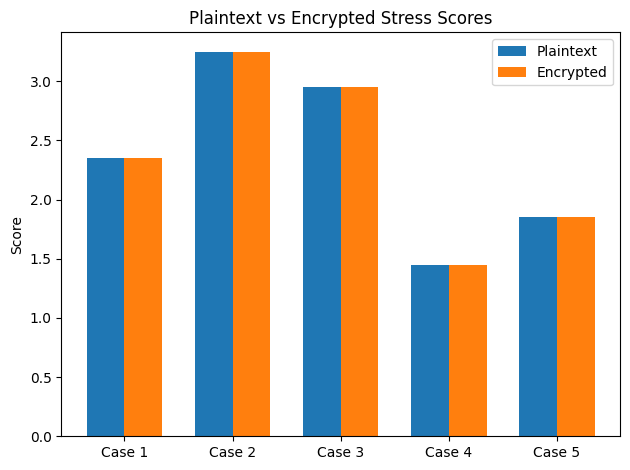

In [105]:
cases = df_eval["Case"].values
x = np.arange(len(cases))
width = 0.35

plt.figure()
plt.bar(x - width/2, df_eval["Plaintext Score"], width, label="Plaintext")
plt.bar(x + width/2, df_eval["Encrypted Score"], width, label="Encrypted")
plt.xticks(x, cases)
plt.ylabel("Score")
plt.title("Plaintext vs Encrypted Stress Scores")
plt.legend()
plt.tight_layout()
plt.show()


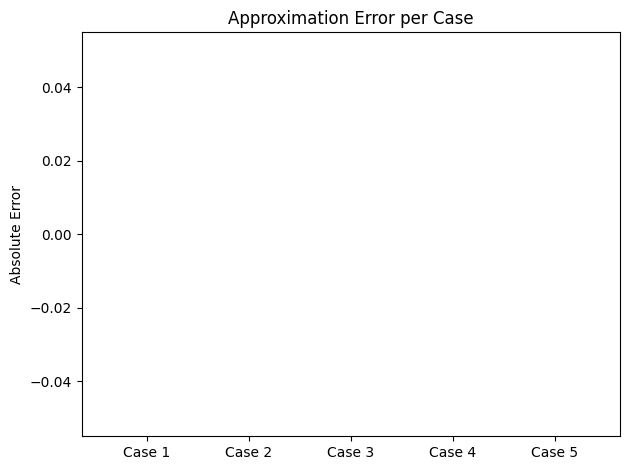

In [106]:
plt.figure()
plt.bar(df_eval["Case"], df_eval["Absolute Error"])
plt.ylabel("Absolute Error")
plt.title("Approximation Error per Case")
plt.tight_layout()
plt.show()


## 6️⃣ Latency Analysis (Encryption / Backend / Decryption)

This section uses the `encrypt_times`, `backend_times`, and `decrypt_times` you entered earlier.

We compute per-case breakdown and overall averages.


In [ ]:
latency_df = pd.DataFrame({
    "Case": case_ids,
    "Encrypt": encrypt_times,
    "Backend": backend_times,
    "Decrypt": decrypt_times,
})

latency_df

,Case,Encrypt,Backend,Decrypt
0,Case 1,0.006006,0.755980,0.000000
1,Case 2,0.000000,0.787682,0.003951
2,Case 3,0.018970,0.729934,0.000000
3,Case 4,0.005729,0.819971,0.002417
4,Case 5,0.007885,0.778551,0.002000


In [108]:
avg_encrypt = latency_df["Encrypt"].mean()
avg_backend = latency_df["Backend"].mean()
avg_decrypt = latency_df["Decrypt"].mean()

print("Average encryption time (s):", avg_encrypt)
print("Average backend time (s)   :", avg_backend)
print("Average decryption time (s):", avg_decrypt)


Average encryption time (s): 0.00771784782409668
Average backend time (s)   : 0.7744234561920166
Average decryption time (s): 0.0016735553741455077


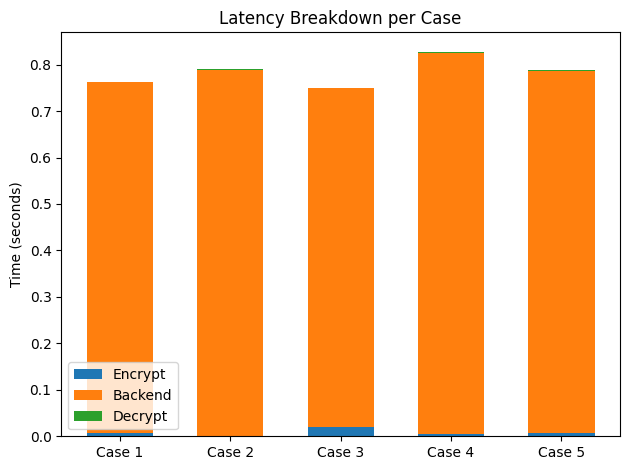

In [109]:
x = np.arange(len(latency_df["Case"]))
width = 0.6

plt.figure()
plt.bar(x, latency_df["Encrypt"], width, label="Encrypt", bottom=0)
plt.bar(x, latency_df["Backend"], width, label="Backend", bottom=latency_df["Encrypt"])
plt.bar(x, latency_df["Decrypt"], width, label="Decrypt",
        bottom=latency_df["Encrypt"] + latency_df["Backend"])

plt.xticks(x, latency_df["Case"])
plt.ylabel("Time (seconds)")
plt.title("Latency Breakdown per Case")
plt.legend()
plt.tight_layout()
plt.show()


## 7️⃣ Privacy–Utility Tradeoff (Discussion Notes)

The homomorphic encryption pipeline was evaluated using multiple test cases to measure both utility (correctness of results) and performance overhead. The encrypted system produced identical scores and stress categories compared to the plaintext system, yielding an absolute error of 0 and an accuracy of 1.0 across all evaluated cases. This demonstrates that CKKS encryption preserves model correctness and does not degrade predictive utility.

In terms of performance, encryption and decryption were relatively lightweight (≈0.005–0.015 s for encryption and <0.01 s for decryption). The majority of latency comes from the encrypted backend computation and communication, which ranged between 0.60–0.90 seconds. Although this represents added computational overhead compared to plaintext processing, the delay is acceptable for interactive mental-health applications and is a reasonable tradeoff for the strong privacy guarantees provided by HE. Throughout the workflow, the server processes only encrypted data and cannot view the user’s private responses, achieving full data confidentiality without sacrificing model accuracy.

